In [2]:
import os
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({
    'savefig.dpi':900,
    'savefig.bbox':'tight',
    'savefig.pad_inches':0.02,
    'tick.minor':False,
    'font.size':9,
    'label.size':9,
    'tick.labelsize':9,
    'title.size':9,
    'abc.size':9,
    'legend.fontsize':9,
    'suptitle.size':9,
    'leftlabelsize':9,
    'toplabelsize':9,
    'leftlabel.weight':'normal',
    'toplabel.weight':'normal',
    'reso':'xx-hi'})

In [3]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR = CONFIGS['filepaths']['splits']
MODELSDIR = CONFIGS['filepaths']['models']
PREDSDIR  = CONFIGS['filepaths']['predictions']
MODELS    = CONFIGS['experiments']
SPLIT     = 'test'

MODELDICT = {}
for name,config in MODELS['pod']['runs'].items():
    MODELDICT[name] = {'label':config['description'],'color':config['color'],'marker':'x'}
for name,config in MODELS['nn']['runs'].items():
    MODELDICT[name] = {'label':config['description'],'color':config['color'],'marker':'D'}
for name,config in MODELS['sr']['optimizedeqs'].items():
    MODELDICT[name] = {'label':config['description'],'color':config['color'],'marker':'o'}

In [4]:
def get_r2(ytrue,ypred,dims=None):
    dims = list(ytrue.dims) if dims is None else dims
    ssres = ((ytrue-ypred)**2).sum(dim=dims,skipna=True)
    sstot = ((ytrue-ytrue.mean(dim=dims,skipna=True))**2).sum(dim=dims,skipna=True)
    return float(1-ssres/sstot)

def get_mse(ytrue,ypred,dims=None):
    dims = list(ytrue.dims) if dims is None else dims
    return float(((ytrue-ypred)**2).mean(dim=dims,skipna=True))

def get_nn_complexity(kind,nfieldvars,nlevs,nlocalvars):
    def nparams(nfeatures):
        return (nfeatures*256)+256+(256*128)+128+(128*64)+64+(64*32)+32+(32*1)+1
    if kind=='baseline':return nparams(nfieldvars*nlevs+nlocalvars)
    if kind=='nonparametric':return nfieldvars*nlevs+nparams(nfieldvars+nlocalvars)
    if kind=='parametric':return 2*nfieldvars+nparams(nfieldvars+nlocalvars)

def get_mse_at_r2(ytrue,target,dims=None):
    dims  = list(ytrue.dims) if dims is None else dims
    sstot = ((ytrue-ytrue.mean(dim=dims,skipna=True))**2).sum(dim=dims,skipna=True)
    return float((1-target)*sstot/ytrue.count(dim=dims))

def pareto_front(records):
    ordered,front,best = sorted(records,key=lambda r:r['mse']),[],np.inf
    for r in ordered:
        if r['nparams']<best:
            front.append(r)
            best = r['nparams']
    return sorted(front,key=lambda r:r['nparams'])

def get_target_nparams(name,nsigs):
    if name in MODELS['pod']['runs']:
        with np.load(os.path.join(MODELSDIR,'pod',f'{name}.npz')) as d:
            return int(d['nparams'])
    if name in MODELS['nn']['runs']:
        config = MODELS['nn']['runs'][name]
        return get_nn_complexity(config['kind'],len(config['fieldvars']),nsigs,len(config.get('localvars',[])))
    if name in MODELS['sr'].get('optimizedeqs',{}):
        return MODELS['sr']['optimizedeqs'][name]['refcomplexity']

In [5]:
with xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf') as ds:
    truetp = ds.tp.load()

with xr.open_dataset(os.path.join(SPLITSDIR,'norm_train.h5'),engine='h5netcdf') as ds:
    firstvar = next(iter(MODELS['nn']['runs'].values()))['fieldvars'][0]
    nsigs    = ds.sizes['sig'] if 'sig' in ds[firstvar].dims else 1

results = {}
for name in MODELDICT:
    filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(filepath):continue
    with xr.open_dataset(filepath) as ds:
        predtp = ds.tp.load()
    r2seeds = None
    if 'seed' in predtp.dims and predtp.sizes['seed']>1:
        r2seeds = np.array([get_r2(*xr.align(truetp,predtp.sel(seed=s).squeeze(),join='inner')) for s in predtp.seed.values])
    if 'seed' in predtp.dims:predtp = predtp.mean('seed')
    if 'complexity' in predtp.dims:predtp = predtp.isel(complexity=0)
    ytrue,ypred = xr.align(truetp,predtp,join='inner')
    ytrue,ypred = ytrue.squeeze(),ypred.squeeze()
    results[name] = {
        'ytrue':ytrue,'ypred':ypred,
        'r2':float(r2seeds.mean()) if r2seeds is not None else get_r2(ytrue,ypred),
        'mse':get_mse(ytrue,ypred),
        'nparams':get_target_nparams(name,nsigs)}

pareto = {}
for name in MODELS['sr']['runs']:
    filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
    if not os.path.exists(filepath):continue
    with xr.open_dataset(filepath) as ds:
        predtp = ds.tp.load()
    if 'seed' in predtp.dims:predtp = predtp.mean('seed')
    if 'complexity' not in predtp.dims:continue
    ytrue,ypred = xr.align(truetp,predtp,join='inner')
    pareto[name] = (ytrue.squeeze(),ypred.squeeze())

print(f'{len(results)}/{len(MODELDICT)} models loaded!')

10/10 models loaded!


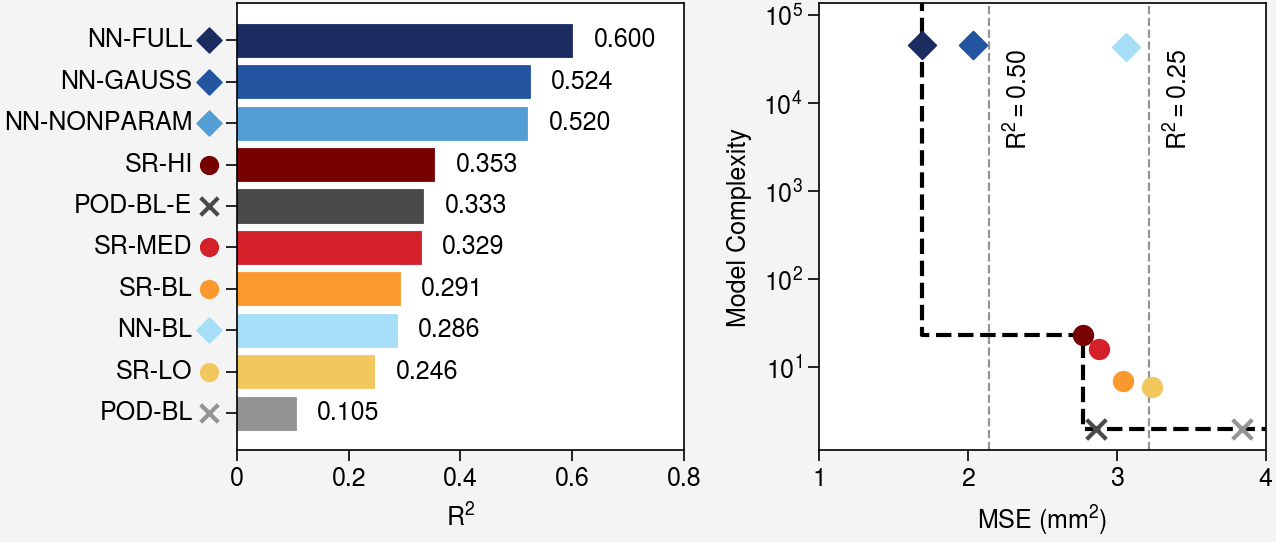

In [6]:
front = []
for run,(ytrue,ypred) in pareto.items():
    for c in ypred.complexity.values:
        front.append(dict(mse=get_mse(ytrue,ypred.sel(complexity=int(c))),nparams=int(c)))
for name,r in results.items():
    if r['nparams'] is None:continue
    front.append(dict(mse=r['mse'],nparams=r['nparams']))
front   = pareto_front(front) if front else []
mserefs = {r2:get_mse_at_r2(truetp,target=r2) for r2 in [0.25,0.5]}

rows   = sorted(results.items(),key=lambda x:x[1]['r2'])
labels = [MODELDICT[n]['label'] for n,_ in rows]
colors = [MODELDICT[n]['color'] for n,_ in rows]
r2s    = [r['r2'] for _,r in rows]

fig,axs = pplt.subplots(ncols=2,figwidth=6.5,refwidth=2,share=False,tight=True)
axs[0].barh(labels,r2s,color=colors)
for i,(name,_) in enumerate(rows):
    axs[0].scatter(-0.05,i,marker=MODELDICT[name]['marker'],color=MODELDICT[name]['color'],markersize=40,clip_on=False)
axs[0].set_yticks(range(len(labels)))
axs[0].set_yticklabels([])
for i,label in enumerate(labels):
    axs[0].text(-0.08,i,label,va='center',ha='right')
for i,(name,r) in enumerate(rows):
    axs[0].text(max(r['r2']+0.15,0.01),i,f"{r['r2']:.3f}",va='center',ha='right')
axs[0].format(grid=False,xlabel=r'$R^2$',xlim=(0,0.8))
if front:
    mses    = [r['mse'] for r in front]
    nparams = [r['nparams'] for r in front]
    ymax    = max(r['nparams'] for r in results.values() if r['nparams'] is not None) * 3
    ext_mse    = [999]       + mses    + [mses[-1]]
    ext_nparams = [nparams[0]] + nparams + [ymax]
    axs[1].plot(ext_mse,ext_nparams,color='k',linestyle='--',zorder=3,drawstyle='steps-post')
else:
    ymax = None
for name,r in results.items():
    if r['nparams'] is None:continue
    axs[1].scatter(r['mse'],r['nparams'],color=MODELDICT[name]['color'],marker=MODELDICT[name]['marker'],markersize=50,zorder=6,label=MODELDICT[name]['label'])
for r2,mse in mserefs.items():
    axs[1].axvline(mse,color='gray',linestyle='--',linewidth=0.8)
    axs[1].text(mse+0.1,0.9,rf'$R^2={r2:.2f}$',rotation=90,va='top',ha='left',transform=axs[1].get_xaxis_transform())
axs[1].format(grid=False,xlabel=r'MSE (mm$^2$)',xlim=(1,4),ylim=(None,ymax),ylabel='Model Complexity',yscale='log',yformatter='log')
pplt.show()
fig.save('../figs/fig_1.jpg')